In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from PIL import Image

In [2]:
df_projections=pd.read_csv(r'../data/raw/indiana_projections.csv')
df_projections.head()

,uid,filename,projection
0,1,1_IM-0001-4001.dcm.png,Frontal
1,1,1_IM-0001-3001.dcm.png,Lateral
2,2,2_IM-0652-1001.dcm.png,Frontal
3,2,2_IM-0652-2001.dcm.png,Lateral
4,3,3_IM-1384-1001.dcm.png,Frontal


In [3]:
df_reports=pd.read_csv(r'../data/raw/indiana_reports.csv')
df_reports.head()

,uid,MeSH,Problems,image,indication,comparison,findings,impression
0,1,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,2,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
2,3,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."
3,4,"Pulmonary Disease, Chronic Obstructive;Bullous...","Pulmonary Disease, Chronic Obstructive;Bullous...","PA and lateral views of the chest XXXX, XXXX a...",XXXX-year-old XXXX with XXXX.,None available,There are diffuse bilateral interstitial and a...,1. Bullous emphysema and interstitial fibrosis...
4,5,Osteophyte/thoracic vertebrae/multiple/small;T...,Osteophyte;Thickening;Lung,Xray Chest PA and Lateral,Chest and nasal congestion.,NaN,The cardiomediastinal silhouette and pulmonary...,No acute cardiopulmonary abnormality.


### `First we need to understand what is this columns`

# Chest X-ray Reports Dataset Explanation

This dataset contains medical reports related to chest X-ray examinations.

Each row represents a medical report for a patient. The dataset includes clinical information, doctor observations, and the final diagnosis.

Columns description:

- **uid**: Unique identifier for each medical report.
- **MeSH**: Medical Subject Headings that describe diseases or medical conditions found in the report.
- **Problems**: List of detected medical problems in the chest X-ray.
- **image**: Description of the X-ray image type (for example: PA and Lateral chest X-ray).
- **indication**: The medical reason why the X-ray was requested.
- **comparison**: Indicates whether the current X-ray is compared with a previous study.
- **findings**: Detailed observations made by the radiologist after analyzing the X-ray image.
- **impression**: The final medical conclusion or diagnosis based on the findings.

This dataset is commonly used in medical Natural Language Processing (NLP) and machine learning tasks such as disease classification, report summarization, or automated diagnosis.

In [4]:
df_pro_rep=pd.DataFrame()
df_pro_rep=pd.merge(df_projections,df_reports,on='uid')

In [5]:
df_pro_rep.head()

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression
0,1,1_IM-0001-4001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,1,1_IM-0001-3001.dcm.png,Lateral,normal,normal,Xray Chest PA and Lateral,Positive TB test,None.,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,2,2_IM-0652-1001.dcm.png,Frontal,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,2,2_IM-0652-2001.dcm.png,Lateral,Cardiomegaly/borderline;Pulmonary Artery/enlarged,Cardiomegaly;Pulmonary Artery,"Chest, 2 views, frontal and lateral",Preop bariatric surgery.,None.,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
4,3,3_IM-1384-1001.dcm.png,Frontal,normal,normal,Xray Chest PA and Lateral,"rib pain after a XXXX, XXXX XXXX steps this XX...",NaN,NaN,"No displaced rib fractures, pneumothorax, or p..."


In [6]:
df_pro_rep.duplicated().sum()

np.int64(0)

In [7]:
df_pro_rep.isna().sum()

uid              0
filename         0
projection       0
MeSH             0
Problems         0
image            0
indication     159
comparison    2260
findings       997
impression      52
dtype: int64

In [8]:
df_pro_rep["indication"].value_counts()

indication
Chest pain                                                                                          253
XXXX                                                                                                223
Chest pain.                                                                                         171
chest pain                                                                                          120
XXXX.                                                                                               115
                                                                                                   ... 
XXXX-year-old XXXX, status post ICD/pacemaker placement.                                              1
XXXX-year-old male with asthma                                                                        1
XXXX-year-old woman with hypertension.                                                                1
Post pacemaker implantation unable to raise left arm 

In [9]:
df_pro_rep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7466 entries, 0 to 7465
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   uid         7466 non-null   int64 
 1   filename    7466 non-null   object
 2   projection  7466 non-null   object
 3   MeSH        7466 non-null   object
 4   Problems    7466 non-null   object
 5   image       7466 non-null   object
 6   indication  7307 non-null   object
 7   comparison  5206 non-null   object
 8   findings    6469 non-null   object
 9   impression  7414 non-null   object
dtypes: int64(1), object(9)
memory usage: 583.4+ KB


In [10]:
df_pro_rep.dropna(subset=["indication","impression"],inplace=True)

In [11]:
df_pro_rep.isna().sum()

uid              0
filename         0
projection       0
MeSH             0
Problems         0
image            0
indication       0
comparison    2168
findings       941
impression       0
dtype: int64

In [12]:
df_pro_rep["comparison"].value_counts()

comparison
None.                                             1564
XXXX                                               529
XXXX, XXXX.                                        409
XXXX, XXXX                                         302
None available.                                    256
                                                  ... 
XXXX, XXXX XXXX hours                                1
Chest XXXX. Clinical                                 1
Single view chest radiograph dated XXXX, XXXX.       1
Sternum radiograph XXXX, XXXX                        1
Unavailable                                          1
Name: count, Length: 383, dtype: int64

In [13]:
df_pro_rep["comparison"].replace(["XXXX","XXXX, XXXX.","XXXX, XXXX","None."],"None",regex=True,inplace=True)

C:\Users\mohma\AppData\Local\Temp\ipykernel_3964\3921676669.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pro_rep["comparison"].replace(["XXXX","XXXX, XXXX.","XXXX, XXXX","None."],"None",regex=True,inplace=True)


In [14]:
df_pro_rep["comparison"].value_counts()

comparison
None                                                    2095
None, None.                                              409
None, None                                               302
Noneavailable.                                           256
None.                                                    236
                                                        ... 
PA and lateral chest x-None dated None                     1
Chest None. Clinical                                       1
None, None None hours                                      1
79 None                                                    1
CT chest None, None and chest radiograph None, None.       1
Name: count, Length: 380, dtype: int64

In [ ]:
df_pro_rep['comparison'] = df_pro_rep['comparison'].str.replace(r'XXXX|None\.|\.', '', regex=True)

In [ ]:
df_pro_rep['comparison'] = df_pro_rep['comparison'].fillna('Unknown')

In [17]:
df_pro_rep.isna().sum()

uid             0
filename        0
projection      0
MeSH            0
Problems        0
image           0
indication      0
comparison      0
findings      941
impression      0
dtype: int64

In [18]:
df_pro_rep["findings"].value_counts()

findings
The heart is normal in size. The mediastinum is unremarkable. The lungs are clear.                                                                                                                                                                                                                                                                                                            92
The heart and lungs have XXXX XXXX in the interval. Both lungs are clear and expanded. Heart and mediastinum normal.                                                                                                                                                                                                                                                                          89
Heart size normal. Lungs are clear. XXXX are normal. No pneumonia, effusions, edema, pneumothorax, adenopathy, nodules or masses.                                                                                            

In [19]:
len(df_pro_rep)

7295

In [20]:
df_pro_rep[["findings","impression"]]

,findings,impression
0,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
3,Borderline cardiomegaly. Midline sternotomy XX...,No acute pulmonary findings.
4,NaN,"No displaced rib fractures, pneumothorax, or p..."
...,...,...
7461,"Heart size within normal limits. Small, nodula...","No acute findings, no evidence for active TB."
7462,NaN,Heart size is normal and the lungs are clear.
7463,NaN,Heart size is normal and the lungs are clear.
7464,NaN,The cardiac silhouette is normal in size and c...


In [21]:
df_pro_rep[df_pro_rep["findings"].isna()][["findings","impression"]]

,findings,impression
4,NaN,"No displaced rib fractures, pneumothorax, or p..."
5,NaN,"No displaced rib fractures, pneumothorax, or p..."
40,NaN,Heart size normal. Mediastinal silhouettes and...
41,NaN,Heart size normal. Mediastinal silhouettes and...
56,NaN,Borderline heart size. Elevated left diaphragm...
...,...,...
7451,NaN,Prior sternotomy. Midline sternotomy XXXX. Nor...
7462,NaN,Heart size is normal and the lungs are clear.
7463,NaN,Heart size is normal and the lungs are clear.
7464,NaN,The cardiac silhouette is normal in size and c...


In [ ]:
df_pro_rep['findings'] = df_pro_rep['findings'].fillna(df_pro_rep['impression'])  # استخدم impression إذا كان findings فارغ
df_pro_rep['findings'] = df_pro_rep['findings'].str.replace('XXXX', '', regex=False)

In [23]:
df_pro_rep.isna().sum()

uid           0
filename      0
projection    0
MeSH          0
Problems      0
image         0
indication    0
comparison    0
findings      0
impression    0
dtype: int64

In [24]:
df_pro_rep[["findings","impression"]].head()

,findings,impression
0,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
1,The cardiac silhouette and mediastinum size ar...,Normal chest x-XXXX.
2,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.
3,Borderline cardiomegaly. Midline sternotomy . ...,No acute pulmonary findings.
4,"No displaced rib fractures, pneumothorax, or p...","No displaced rib fractures, pneumothorax, or p..."


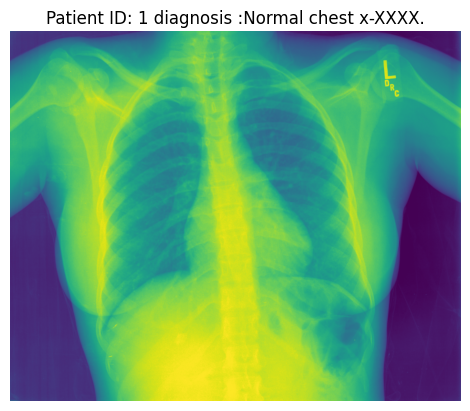

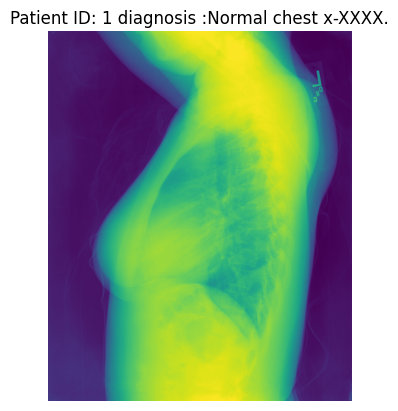

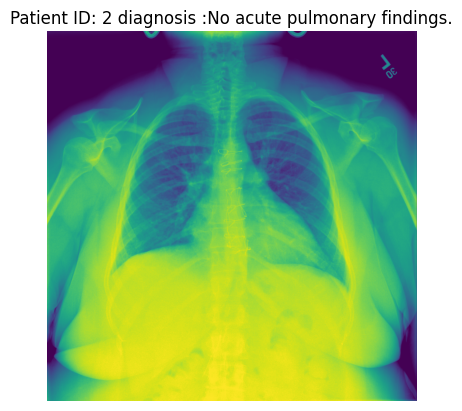

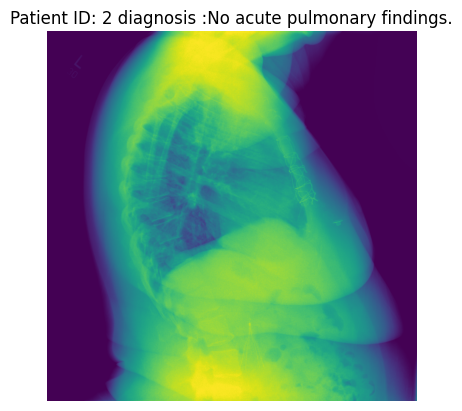

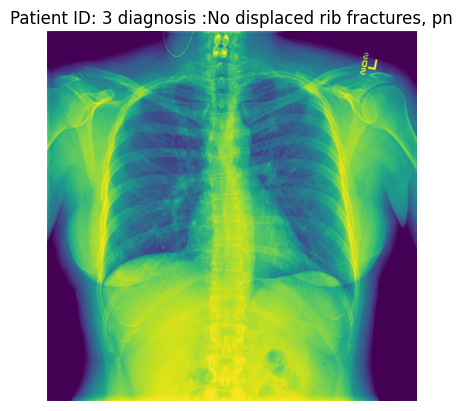

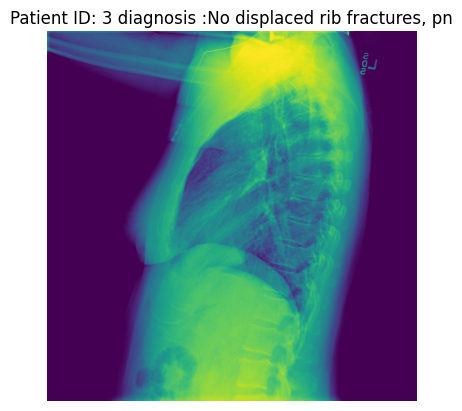

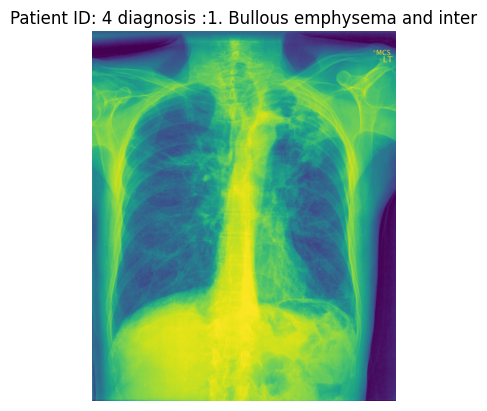

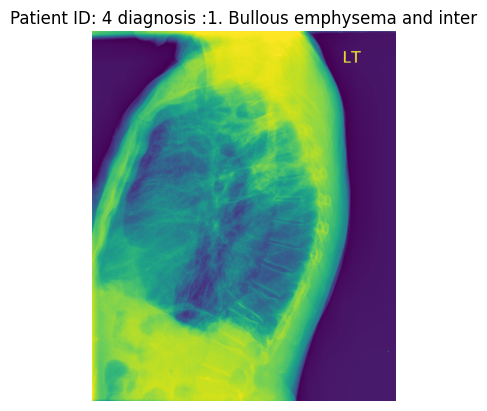

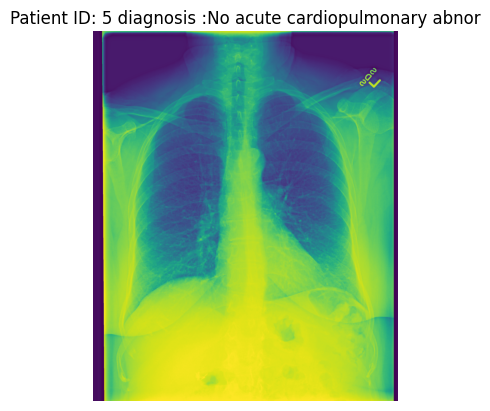

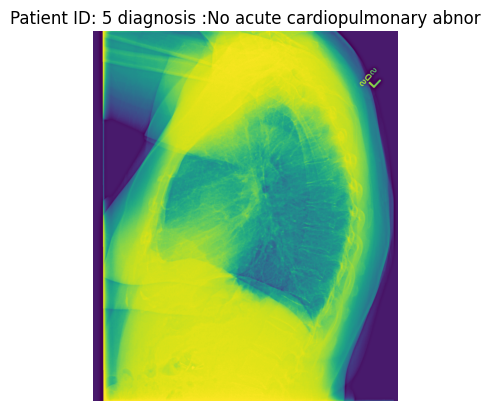

In [25]:
sample = df_pro_rep.head(10)

img_path = r"../data/raw/images/images_normalized"

for i, row in sample.iterrows():
    
    uid = row["uid"]
    filename = row["filename"]
    
    path = os.path.join(img_path, filename)
    
    img = Image.open(path)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Patient ID: {uid}"+f" diagnosis :{row["impression"][:30]}")
    plt.axis("off")

In [26]:
df_pro_rep["Problems"].value_counts()

Problems
normal                                                                              2596
Lung                                                                                 173
No Indexing                                                                          162
Calcified Granuloma                                                                  159
Thoracic Vertebrae                                                                   111
                                                                                    ... 
Opacity;Atherosclerosis;Thoracic Vertebrae                                             1
Opacity;Aorta, Thoracic;Opacity;Pulmonary Atelectasis;Cicatrix                         1
Opacity;Pneumonia;Lung                                                                 1
Cardiomegaly;Calcinosis;Implanted Medical Device;Diaphragm;Pulmonary Atelectasis       1
Markings;Lung;Infiltrate;Pulmonary Fibrosis                                            1
Name: count,

Top 20 Impressions:
impression
The cardiac silhouette is normal in size and configuration. The mediastinum and perihilar structures appear unremarkable. The lungs appear clear. The osseous structures are within normal limits.                                                                                                                                       1
Normal chest x-                                                                                                                                                                                                                                                                                                                          1
No acute pulmonary findings.                                                                                                                                                                                                                                                                                       

C:\Users\mohma\AppData\Local\Temp\ipykernel_3964\1657175194.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['impression_class'] = df['impression'].apply(classify_impression)


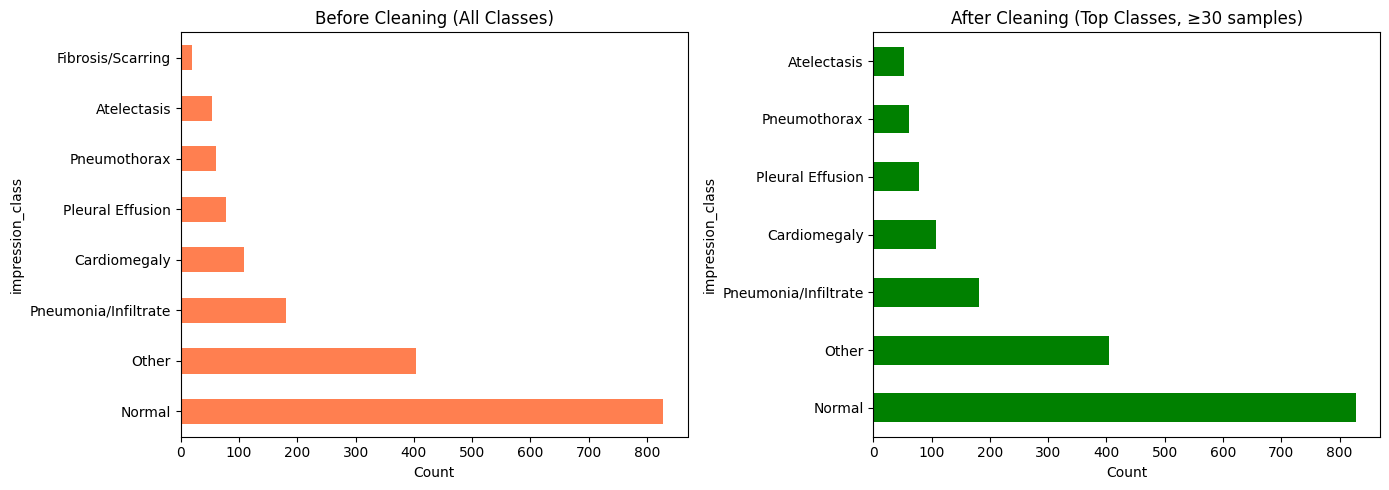

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import re

# تحميل البيانات

# ✅ 1. تنظيف النصوص - إزالة المسافات الزائدة والعلامات الخاصة
df_pro_rep['impression'] = df_pro_rep['impression'].str.strip()  # إزالة المسافات من الطرفين
df_pro_rep['impression'] = df_pro_rep['impression'].str.replace(r'\s+', ' ', regex=True)  # مسافة واحدة فقط
df_pro_rep['impression'] = df_pro_rep['impression'].str.replace(r'XXXX.*?\.', '', regex=True)  # إزالة XXXX
df_pro_rep['impression'] = df_pro_rep['impression'].fillna('Unknown')  # للقيم الفارغة

# ✅ 2. حذف الصفوف المكررة
df = df_pro_rep.copy()

# ✅ 3. تظهر الفئات الرئيسية (Top 20)
top_20 = df['impression'].value_counts().head(20)
print("="*60)
print("Top 20 Impressions:")
print("="*60)
print(top_20)
print(f"\nإجمالي الفئات بعد التنظيف: {df['impression'].nunique()}")


def classify_impression(text):
    text_lower = text.lower()
    
    # قائمة الأمراض الشائعة
    if any(word in text_lower for word in ['no acute', 'no active', 'normal']):
        return 'Normal'
    elif 'pneumothorax' in text_lower:
        return 'Pneumothorax'
    elif any(word in text_lower for word in ['infiltrate', 'pneumonia', 'consolidation']):
        return 'Pneumonia/Infiltrate'
    elif 'effusion' in text_lower:
        return 'Pleural Effusion'
    elif 'cardiomegaly' in text_lower:
        return 'Cardiomegaly'
    elif 'atelectasis' in text_lower:
        return 'Atelectasis'
    elif any(word in text_lower for word in ['fibrosis', 'scarring']):
        return 'Fibrosis/Scarring'
    else:
        return 'Other'


df['impression_class'] = df['impression'].apply(classify_impression)

print("\n" + "="*60)
print("Distribution After Classification:")
print("="*60)
print(df['impression_class'].value_counts())
print(f"\nإجمالي الفئات الجديدة: {df['impression_class'].nunique()}")


min_samples = 30
class_counts = df['impression_class'].value_counts()
valid_classes = class_counts[class_counts >= min_samples].index
df_cleaned = df[df['impression_class'].isin(valid_classes)].copy()

print("\n" + "="*60)
print(f"After Removing Classes < {min_samples} Samples:")
print("="*60)
print(df_cleaned['impression_class'].value_counts())
print(f"\nعدد العينات المتبقية: {len(df_cleaned)} من {len(df)}")
print(f"عدد الفئات: {df_cleaned['impression_class'].nunique()}")


import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
df['impression_class'].value_counts().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Before Cleaning (All Classes)')
axes[0].set_xlabel('Count')

# After
df_cleaned['impression_class'].value_counts().plot(kind='barh', ax=axes[1], color='green')
axes[1].set_title(f'After Cleaning (Top Classes, ≥{min_samples} samples)')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()



In [32]:
df.sample(3)

,uid,filename,projection,MeSH,Problems,image,indication,comparison,findings,impression,impression_class
2185,1170,1170_IM-0115-2001.dcm.png,Frontal,Cardiomegaly/mild,Cardiomegaly,Chest XXXX and lateral,XXXX-year-old male with chest pain,Noneavailable.,"No pneumothorax, pleural effusion, or focal ai...",Mild cardiomegaly.,Cardiomegaly
3738,2002,2002_IM-0654-1001.dcm.png,Frontal,Deformity/ribs/posterior;Foreign Bodies/multip...,Deformity;Foreign Bodies;Lucency,PA and lateral chest radiograph (2 views) (2 i...,Left rib pain.,CT scan of the thorax on None.,Within the posterior lateral 8th rib there is ...,Possible lower posterior lateral left rib frac...,Normal
6715,3605,3605_IM-1781-1001.dcm.png,Frontal,normal,normal,PA and lateral views of the chest.,"XXXX-year-old female, followup pleural effusio...",PA and lateral view the chest from None.,Heart size within normal limits. No focal airs...,No acute cardiopulmonary findings. Specificall...,Normal


In [ ]:
def safe_str(x):
    try:
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return ""
        return str(x)
    except RecursionError:
        return "[RecursionError]"
    except Exception as e:
        return f"[Error: {type(e).__name__}]"

# Use .map() instead of deprecated .applymap()
df_safe = df_pro_rep.map(safe_str)

# Save
df_cleaned.to_csv("../data/processed/FinalData.csv", index=False)
print("✅ Saved successfully!")

KeyboardInterrupt: 